# Material Function in Simulation Class

Reference: [meep/python/tests/test_user_defined_material.py](https://github.com/NanoComp/meep/blob/bba8d5b8f1653760a0130a35fd314c95cd5e0096/python/tests/test_user_defined_material.py#L63) <br>
Still not working! <br>

In [1]:
import meep as mp
from matplotlib import pyplot as plt
import numpy as np

In [2]:
 resolution = 10
 cell = mp.Vector3(10, 10)
 symmetries = [mp.Mirror(mp.X), mp.Mirror(mp.Y)]
 boundary_layers = [mp.PML(1.0)]
 sources = [mp.Source(src=mp.GaussianSource(0.2, fwidth=0.1),
                      component=mp.Ez,
                      center=mp.Vector3())]

In [3]:
def my_material_func(p):
    R1X = 0.5
    R1Y = 1.0
    R2 = 3.0

    x = p.x
    y = p.y

    # test for point inside inner ellipsoid
    if (x**2 / (R1X**2) + y**2 / (R1Y**2)) < 1.0:
        nn = 1.0
    elif (x**2 / (R2**2) + y**2 / (R2**2)) < 1.0:
        nn = 3.5
    else:
        nn = 1.0

    return mp.Medium(epsilon=nn**2)

In [4]:
sim = mp.Simulation(
            cell_size=cell,
            resolution=resolution,
            symmetries=symmetries,
            boundary_layers=boundary_layers,
            sources=sources,
            material_function=my_material_func,
        )

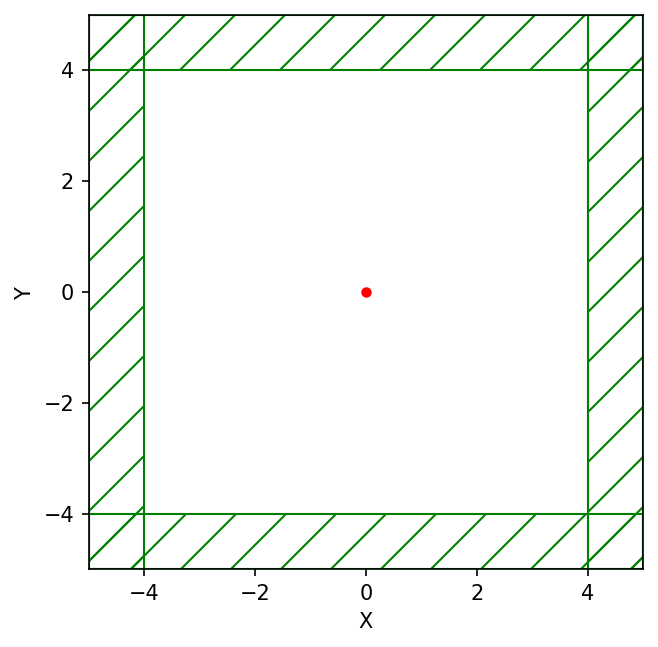

In [5]:
f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()